## packages

In [2]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [3]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [4]:
tw1 = data_preprocess('Blockhouse Data 1.csv')
tw2 = data_preprocess('Blockhouse Data 2.csv')
tw3 = data_preprocess('Blockhouse Data 3.csv')
tw4 = data_preprocess('Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [5]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [6]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [7]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [8]:
filtered_rawdata.shape

(50741, 11)

In [9]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN'] * 10

filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [10]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [11]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [12]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


## daily_vol, adv, beta

In [13]:
filtered_rawdata.MATURITY_RANGE.value_counts()

,count
MATURITY_RANGE,
Note 1.5 - 3.5 Year,12244
Note 0 - 1.5 Year,9955
Note >10 Year,8946
Note 5.5 - 10 Year,8760
Note 3.5 - 5.5 Year,7661
TIPS 0 - 5 year,1620
TIPS > 10 year,782
TIPS 5 - 10 year,773


In [14]:
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == 'Note 1.5 - 3.5 Year']
group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:50:42,D38,1323.10,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,97.101562,1,13231.0,2,0.011719
2023-10-02 07:46:44,D7,2020.00,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,99.351562,1,20200.0,2,0.007812
2023-10-02 08:22:38,D74,202.00,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,96.199219,-1,-2020.0,1,0.019531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,8080.00,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,100.953125,1,80800.0,2,0.015625
2023-12-29 13:50:21,D38,8080.00,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,101.515625,1,80800.0,2,0.011719
2023-12-29 13:50:21,D74,14140.00,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,101.414062,1,141400.0,2,0.011719


In [15]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

In [16]:
group1.Daily_Volatility

,Daily_Volatility
TIMESTAMP,
2023-10-02 06:47:43,3.636997
2023-10-02 06:47:43,3.636997
2023-10-02 06:50:42,3.636997
2023-10-02 07:46:44,3.636997
2023-10-02 08:22:38,3.636997
...,...
2023-12-29 13:50:21,3.605377
2023-12-29 13:50:21,3.605377
2023-12-29 13:50:21,3.605377


In [17]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum() * 10
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [18]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    2029226.35
2023-10-03    2300066.94
2023-10-04    1177301.45
2023-10-05    1162227.20
2023-10-06    2131342.40
2023-10-07          0.00
2023-10-08          0.00
2023-10-09          0.00
2023-10-10    4103338.11
2023-10-11    1181639.40
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [19]:
group1.ADV

,ADV
TIMESTAMP,
2023-10-02 06:47:43,380.218540
2023-10-02 06:47:43,380.218540
2023-10-02 06:50:42,380.218540
2023-10-02 07:46:44,380.218540
2023-10-02 08:22:38,380.218540
...,...
2023-12-29 13:50:21,170.450478
2023-12-29 13:50:21,170.450478
2023-12-29 13:50:21,170.450478


In [20]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 2029226.35
DEC 1177301.45


In [21]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt

In [22]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 30-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [23]:
group1['SIGN'].unique()

array([ 1, -1])

In [24]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME          qt
TIMESTAMP                                     
2023-10-02 06:47:43        39390.0     55600.5
2023-10-02 06:47:43         2979.5     55600.5
2023-10-02 06:50:42        13231.0     55600.5
2023-10-02 07:46:44        20200.0     20200.0
2023-10-02 08:22:38        -2020.0     12776.5
...                            ...         ...
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21        80800.0  10631411.5
2023-12-29 13:50:21       141400.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5
2023-12-29 13:51:07        20200.0  10631411.5

[12244 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00       55600.50
2023-10-02 07:00:00       20200.00
2023-10-02 08:00:00       12776.50
2023-10-02 09:00:00       45106.60
2023-10-02 10:00:00      385991.70
                          ...     
2023-12-29 09:00:00      172260.55
2023-12-29 10:00:00     4229462.87
2023-12-29 11:00:00     -788880.70
2023-12-29 12:00:00     7086503.40
202

In [25]:
(group1.qt == 0).value_counts()

,count
qt,
False,12244


In [26]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda

In [27]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [28]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472     0.000020     0.002903
      12.0     3.465736     0.000012     0.002805
      18.0     2.310491     0.000008     0.002196
      24.0     1.732868     0.000006     0.002152
      30.0     1.386294     0.000006     0.002449
      48.0     0.866434     0.000002     0.000931
      60.0     0.693147     0.000003     0.003058
      90.0     0.462098     0.000002     0.001335
     120.0     0.346574     0.000002     0.003898
--------------------------------------------------------------------------------


set $\lambda = 0.000002$

In [29]:
def ow(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data


In [30]:
df_it = ow(group1, h_minutes=120, delta_t=1/24)

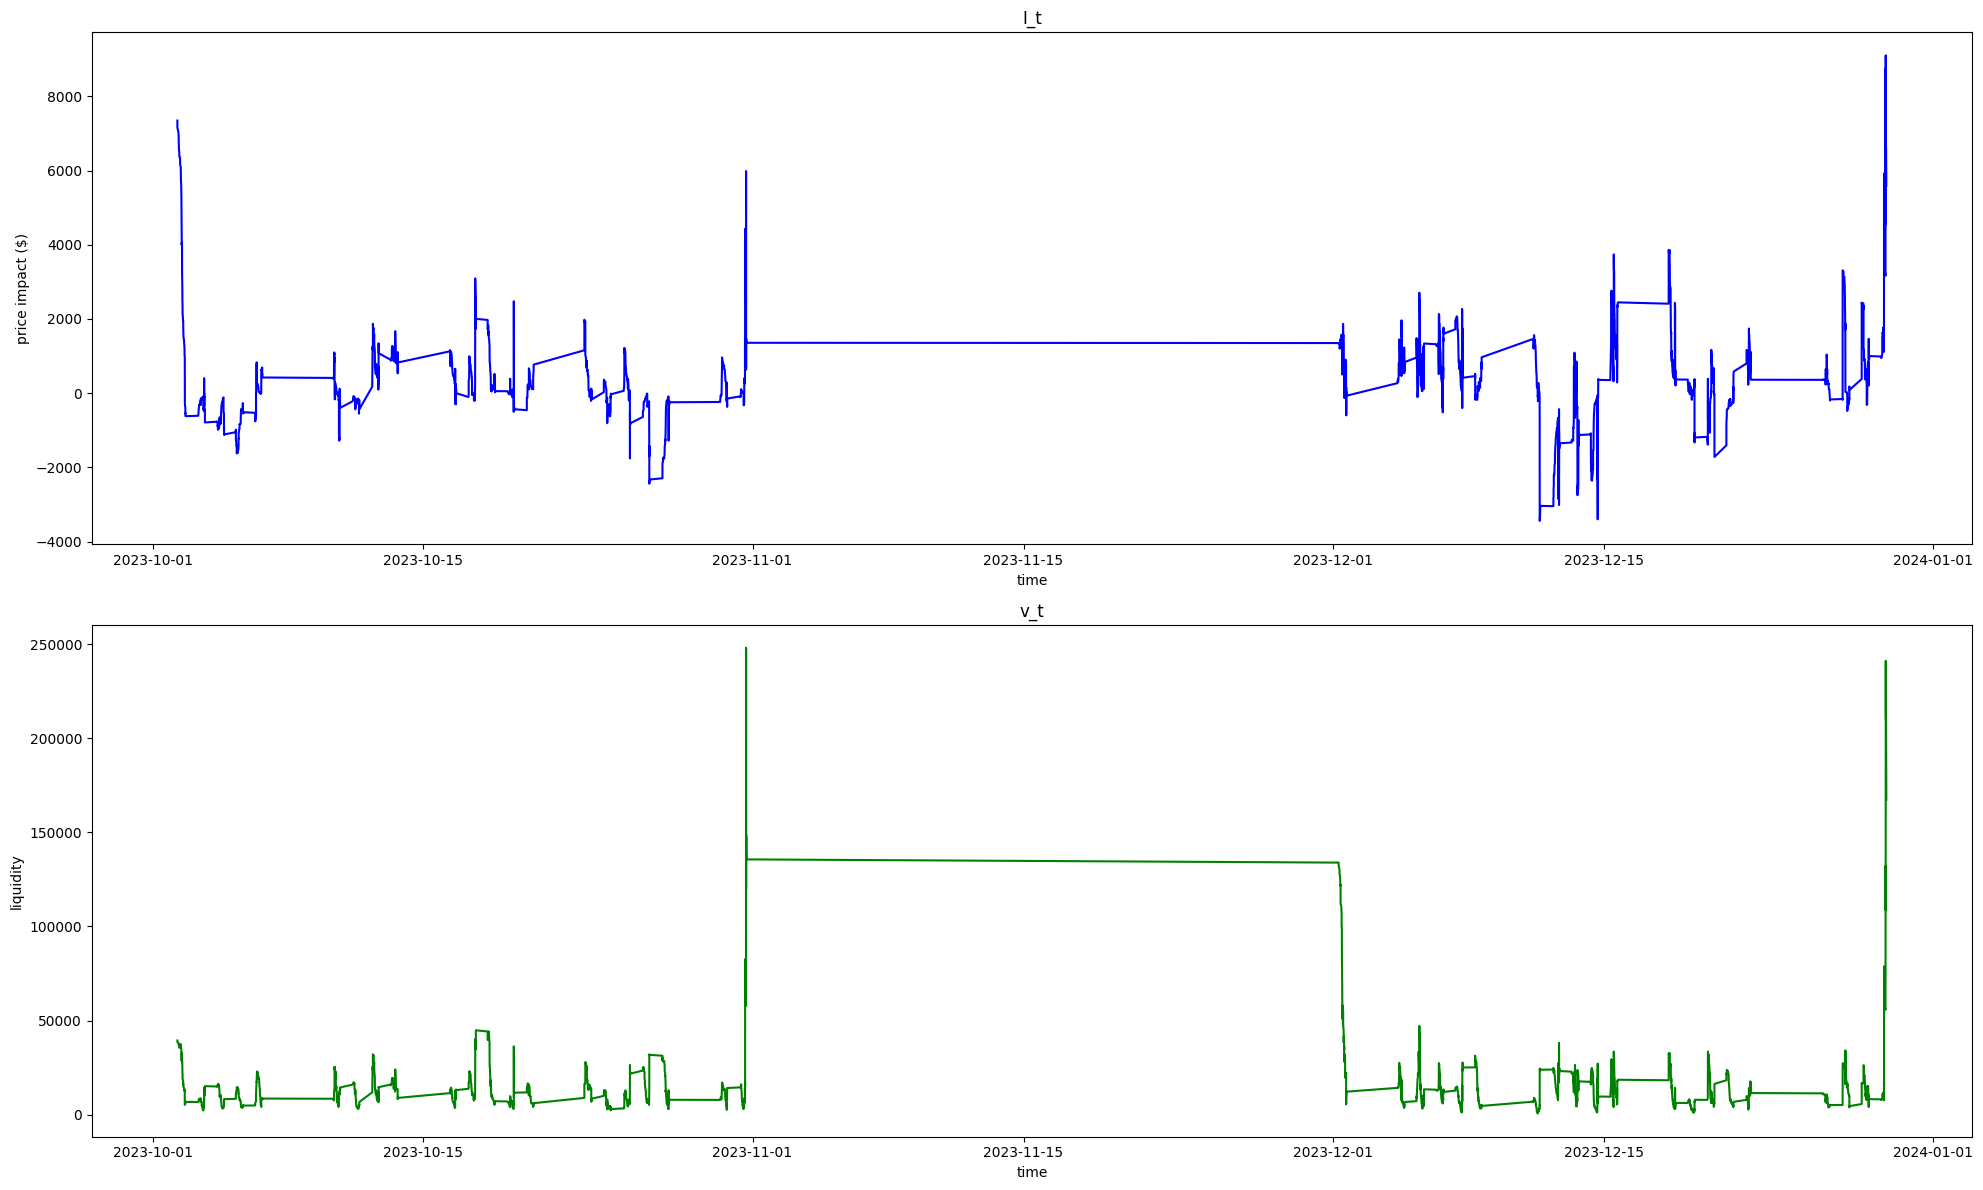

In [31]:
plt.figure(figsize=(20, 12))

# First subplot for df_it.I_t
plt.subplot(2, 1, 1)
plt.plot(df_it.I_t, color='blue')
plt.xlabel('time')
plt.ylabel('price impact ($)')
plt.title('I_t')

# Second subplot for df_it.v_t
plt.subplot(2, 1, 2)
plt.plot(df_it.v_t, color='green')
plt.xlabel('time')
plt.ylabel('liquidity')
plt.title('v_t')

plt.tight_layout()
plt.show()


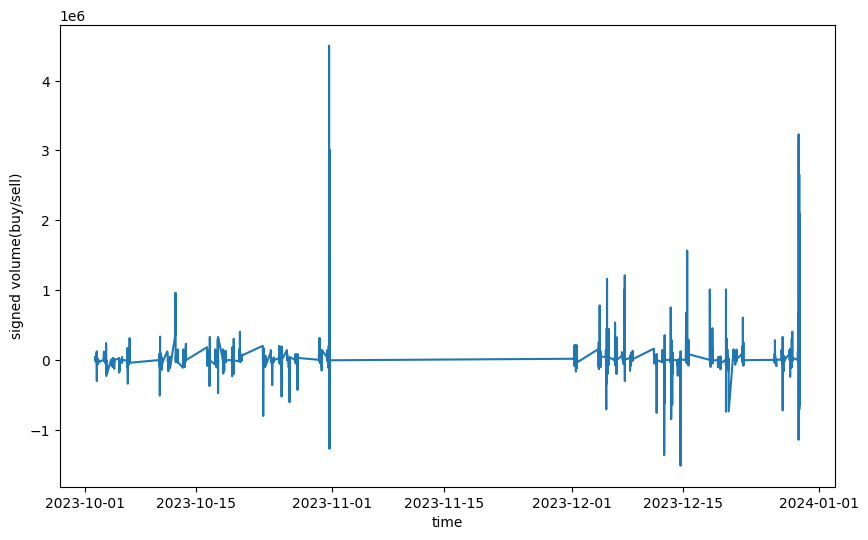

In [32]:
plt.figure(figsize=(10,6))
plt.plot(df_it.SIGNED_VOLUME)
plt.xlabel('time')
plt.ylabel('signed volume(buy/sell)')
plt.show()

In [33]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,20200.00,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,12120.00,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,25250.00,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


In [34]:
# Calculate Slippage
filtered_rawdata['MID'] = (filtered_rawdata['COMP_BID'] + filtered_rawdata['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage_bps(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) / row['MID'] * 10000  # Buy side slippage in bps
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) / row['MID'] * 10000  # Sell side slippage in bps
    return None

filtered_rawdata['Slippage_bps'] = filtered_rawdata.apply(calculate_slippage_bps, axis=1)

In [35]:
filtered_rawdata_oct_dec = filtered_rawdata[(filtered_rawdata.index.month == 10) | (filtered_rawdata.index.month == 12)]

In [45]:
filtered_rawdata['MID'] = (filtered_rawdata['COMP_BID'] + filtered_rawdata['COMP_ASK']) / 2
filtered_rawdata['Slippage_bps'] = filtered_rawdata.apply(calculate_slippage_bps, axis=1)

# Filter data separately for October and December
filtered_rawdata_oct = filtered_rawdata[filtered_rawdata.index.month == 10]
filtered_rawdata_dec = filtered_rawdata[filtered_rawdata.index.month == 12]

filtered_rawdata_oct['Time_Session'] = filtered_rawdata_oct.index.map(assign_time_session)
filtered_rawdata_dec['Time_Session'] = filtered_rawdata_dec.index.map(assign_time_session)

filtered_rawdata_oct['Weighted_Slippage'] = filtered_rawdata_oct['Slippage_bps'] * filtered_rawdata_oct['ACCEPTEDVOL'] * 10

# October volume-weighted average slippage
volume_weighted_slippage_oct = filtered_rawdata_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage_bps_Oct')


filtered_rawdata_dec['Weighted_Slippage'] = filtered_rawdata_dec['Slippage_bps'] * filtered_rawdata_dec['ACCEPTEDVOL'] * 10

#  December volume-weighted average slippage
volume_weighted_slippage_dec = filtered_rawdata_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage'].sum() / (x['SIGNED_VOLUME'].abs().sum() * 10)
).rename('Volume_Weighted_Slippage_bps_Dec')

print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      1.818092
Mid-day        0.114325
Morning        0.170669
Post-market    0.244462
Pre-market     0.091492
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.111983
Mid-day        0.309325
Morning       -0.793967
Post-market   -0.009628
Pre-market     0.010133
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64


In [39]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

filtered_rawdata_oct_dec['Time_Session'] = filtered_rawdata_oct_dec.index.map(assign_time_session)

In [42]:
# Extract month and year for grouping
filtered_rawdata_oct_dec['Year_Month'] = filtered_rawdata_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = filtered_rawdata_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Average_Slippage_bps=('Slippage_bps', 'mean')
)

# Display the results for October and December
print(session_metrics_monthly[['Average_Slippage_bps']])

                         Average_Slippage_bps
Year_Month Time_Session                      
2023-10    Afternoon                -1.244838
           Mid-day                  -1.644153
           Morning                  -1.530340
           Post-market              -0.897534
           Pre-market               -0.643070
2023-12    Afternoon                -0.960855
           Mid-day                  -1.113593
           Morning                  -1.188336
           Post-market              -0.880816
           Pre-market               -0.690273


In [72]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,SIGN,SIGNED_VOLUME,Years to Maturity,Spread,Daily_Volatility,ADV,qt,ABS_VOLUME,I_t,v_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,...,1,39390.0,1,0.005859,3.636997,380.218540,55600.5,39390.0,7347.037658,39390.000000
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,...,1,2979.5,3,0.027344,3.636997,380.218540,55600.5,2979.5,7243.761135,38867.989894
2023-10-02 06:50:42,D38,1323.10,97.109543,91282CGV7,Note 1.5 - 3.5 Year,2026-04-15,2023-10-02,3.750,BUY,97.125000,...,1,13231.0,2,0.011719,3.636997,380.218540,55600.5,13231.0,7151.734384,38500.437463
2023-10-02 07:46:44,D7,2020.00,99.351731,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-10-02,4.625,BUY,99.367188,...,1,20200.0,2,0.007812,3.636997,380.218540,20200.0,20200.0,7067.726982,38238.067726
2023-10-02 08:22:38,D74,202.00,96.214676,91282CEU1,Note 1.5 - 3.5 Year,2025-06-15,2023-10-02,2.875,SELL,96.238281,...,-1,-2020.0,1,0.019531,3.636997,380.218540,12776.5,2020.0,6963.725016,37718.816483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:50:21,D28,8080.00,100.968918,91282CHM6,Note 1.5 - 3.5 Year,2026-07-15,2023-12-29,4.500,BUY,100.984375,...,1,80800.0,2,0.015625,3.605377,170.450478,10631411.5,80800.0,5746.157587,173299.800260
2023-12-29 13:50:21,D38,8080.00,101.523606,91282CJC6,Note 1.5 - 3.5 Year,2026-10-15,2023-12-29,4.625,BUY,101.539062,...,1,80800.0,2,0.011719,3.605377,170.450478,10631411.5,80800.0,5716.985971,171973.648998
2023-12-29 13:50:21,D74,14140.00,101.414231,91282CHY0,Note 1.5 - 3.5 Year,2026-09-15,2023-12-29,4.625,BUY,101.437500,...,1,141400.0,2,0.011719,3.605377,170.450478,10631411.5,141400.0,5728.710452,171535.320666


In [73]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME', 'I_t', 'v_t'],
      dtype='object')

In [75]:
# Calculate Slippage
df_it['MID'] = (df_it['COMP_BID'] + df_it['COMP_ASK']) / 2

# Define slippage calculation function in bps
def calculate_slippage_bps(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) / row['MID'] * 10000  # Buy side slippage in bps
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) / row['MID'] * 10000  # Sell side slippage in bps
    return None

df_it['Slippage_bps'] = df_it.apply(calculate_slippage_bps, axis=1)

In [76]:
df_it['Slippage_bps']

,Slippage_bps
TIMESTAMP,
2023-10-02 06:47:43,-0.570866
2023-10-02 06:47:43,0.018779
2023-10-02 06:50:42,-0.384937
2023-10-02 07:46:44,-0.769379
2023-10-02 08:22:38,0.423436
...,...
2023-12-29 13:50:21,0.016639
2023-12-29 13:50:21,-0.368201
2023-12-29 13:50:21,-1.138838


In [77]:
df_it['Slippage_bps'].max()

28.59137162954299

In [78]:
df_it['Slippage_bps'].min()

-9.075826945562966

In [79]:
# Calculate Signed Volume Weighted Price Impact
df_it['Signed_Volume_Weighted_Impact'] = df_it['SIGNED_VOLUME'] * df_it['I_t']

df_it['Date'] = df_it.index.date
session_metrics = df_it.groupby(['Date', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
    Slippage=('Slippage_bps', 'mean')
)

# Calculate the signed volume weighted price impact
session_metrics['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics['Total_Signed_Volume_Weighted_Impact'] / session_metrics['Total_Signed_Volume'].abs()
)

In [80]:
session_metrics[['Slippage', 'Signed_Volume_Weighted_Price_Impact']]

Slippage  Signed_Volume_Weighted_Price_Impact
Date       Time_Session                                               
2023-10-02 Afternoon    -0.708421                           -36.917313
           Mid-day      -1.137772                           -65.830360
           Morning      -0.656866                           283.789382
           Post-market  -1.079720                             6.003482
           Pre-market   -0.518553                           877.167460
...                           ...                                  ...
2023-12-28 Post-market  -0.674291                             9.574330
           Pre-market   -0.459912                           160.666928
2023-12-29 Mid-day      -0.243737                            55.318801
           Morning      -0.866288                            42.733975
           Pre-market   -0.674506                           128.217010

[201 rows x 2 columns]

In [82]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

# Apply time sessions to the dataframe
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate MID price
df_oct_dec['MID'] = (df_oct_dec['COMP_BID'] + df_oct_dec['COMP_ASK']) / 2

# Calculate Slippage in basis points
df_oct_dec['Slippage_bps'] = df_oct_dec.apply(calculate_slippage_bps, axis=1)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['SIGNED_VOLUME'] * df_oct_dec['I_t']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'sum'),
    Average_Slippage_bps=('Slippage_bps', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] / session_metrics_monthly['Total_Signed_Volume'].abs()
)

# Display the results for October and December
print(session_metrics_monthly[['Average_Slippage_bps', 'Signed_Volume_Weighted_Price_Impact']])

                         Average_Slippage_bps  \
Year_Month Time_Session                         
2023-10    Afternoon                -1.086242   
           Mid-day                  -1.139997   
           Morning                  -1.088216   
           Post-market              -0.875989   
           Pre-market               -0.606285   
2023-12    Afternoon                -0.856073   
           Mid-day                  -0.899434   
           Morning                  -0.846204   
           Post-market              -0.738389   
           Pre-market               -0.563131   

                         Signed_Volume_Weighted_Price_Impact  
Year_Month Time_Session                                       
2023-10    Afternoon                             6495.277210  
           Mid-day                               1775.635244  
           Morning                               8187.548841  
           Post-market                           8049.498437  
           Pre-market            